# Netflix Data Analysis

### Exploratory Data Analysis using Python, Pandas, NumPy and Matplotlib

This project analyzes the Netflix titles dataset to uncover patterns in content types, genres, ratings, countries, directors, actors, release years, content additions, TV show seasons, and movie durations.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Dataset

In [2]:
df = pd.read_csv("../data/NetFlix.csv")

## 3. Understanding the Dataset

In [3]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [4]:
df.size #No. of elements present in the data

93444

In [5]:
df.shape #No. of rows and columns

(7787, 12)

In [6]:
df.columns #Names of all columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'description'],
      dtype='str')

In [7]:
df.info() #To check if there is any null value

<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7787 non-null   str  
 1   type          7787 non-null   str  
 2   title         7787 non-null   str  
 3   director      5398 non-null   str  
 4   cast          7069 non-null   str  
 5   country       7280 non-null   str  
 6   date_added    7777 non-null   str  
 7   release_year  7787 non-null   int64
 8   rating        7780 non-null   str  
 9   duration      7787 non-null   int64
 10  genres        7787 non-null   str  
 11  description   7787 non-null   str  
dtypes: int64(2), str(10)
memory usage: 730.2 KB


In [8]:
df.describe(include="all")

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
count,7787,7787,7787,5398,7069,7280,7777,7787.000000,7780,7787.000000,7787,7787
unique,7787,2,7787,4049,6831,681,1565,NaN,14,NaN,492,7769
top,s1,Movie,3%,"Raúl Campos, Jan Suter",David Attenborough,United States,1-Jan-20,NaN,TV-MA,NaN,Documentaries,Multiple women report their husbands as missin...
freq,1,5377,1,18,18,2555,118,NaN,2863,NaN,334,3
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.932580,NaN,69.122769,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.757395,NaN,50.950743,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,1.000000,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,2.000000,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,88.000000,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2018.000000,NaN,106.000000,NaN,NaN


In [9]:
df.dtypes

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration        int64
genres            str
description       str
dtype: object

## Setting a Consistent Color Gradient for Visualizations

In [10]:
from matplotlib.colors import LinearSegmentedColormap

# Create a reusable black-to-red gradient
cmap = LinearSegmentedColormap.from_list(
    'black_red',
    ['#000000', '#E50914']
)

def netflix_gradient(n):
    if n == 1:
        return ['#E50914']
    return [cmap(i / (n - 1)) for i in range(n)]

## 4. Data Cleaning

In [11]:
df.isnull().sum() #Adds the number of empty values present

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64

In [12]:
#Replace empty cells with "Not Given" string
df["director"] = df["director"].fillna("Not Given") 
df["cast"] = df["cast"].fillna("Not Given")
df["country"] = df["country"].fillna("Not Given")
df["date_added"] = df["date_added"].fillna("Not Given")
df["rating"] = df["rating"].fillna("Not Given")

In [13]:
df.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
genres          0
description     0
dtype: int64

In [14]:
#Checcks whether the whole row have the same info as the other
df.duplicated().sum() #In this case: No

np.int64(0)

In [15]:
#The above warning : It couldn't identify the date format, we need to help it by giving a format
#As we have converted missing values of date_added with "Not Given", we need to turn it back to the missing value
df["date_added"] = df["date_added"].replace("Not Given", pd.NaT) #NaT : Not a Time

In [16]:
df["date_added"] = pd.to_datetime(           
     df["date_added"].str.strip(),                       
    format="mixed"                     
)
df["date_added"].dtype

dtype('<M8[us]')

In [17]:
df.isnull().sum()

show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         0
genres           0
description      0
dtype: int64

## 5. Exploratory Data Analysis

### 5.1 Movies vs TV Shows

In [18]:
df['type'].value_counts(normalize = True) * 100    # normalize helps in proportioning the values

type
Movie      69.050982
TV Show    30.949018
Name: proportion, dtype: float64

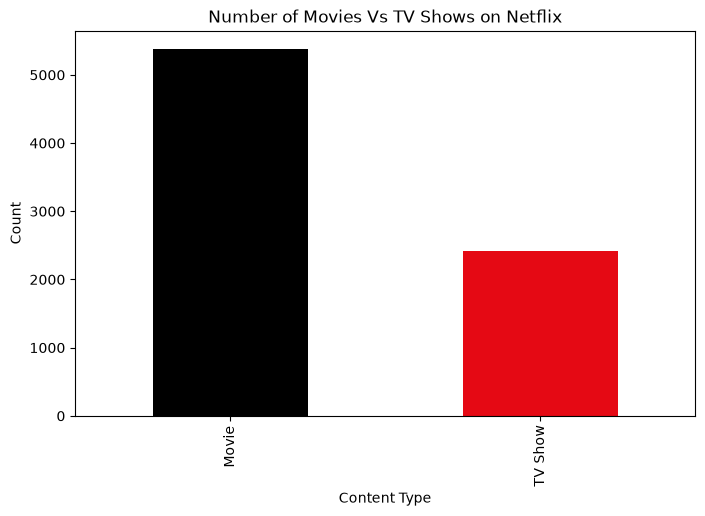

In [19]:
df['type'].value_counts().plot(kind = 'bar', 
                               figsize = (8,5), 
                               color = netflix_gradient(2)
                              )
plt.title("Number of Movies Vs TV Shows on Netflix")
plt.xlabel('Content Type')
plt.ylabel('Count')
plt.show()

### 5.2 Netflix Content Ratings

In [20]:
rating_counts = df["rating"].value_counts()

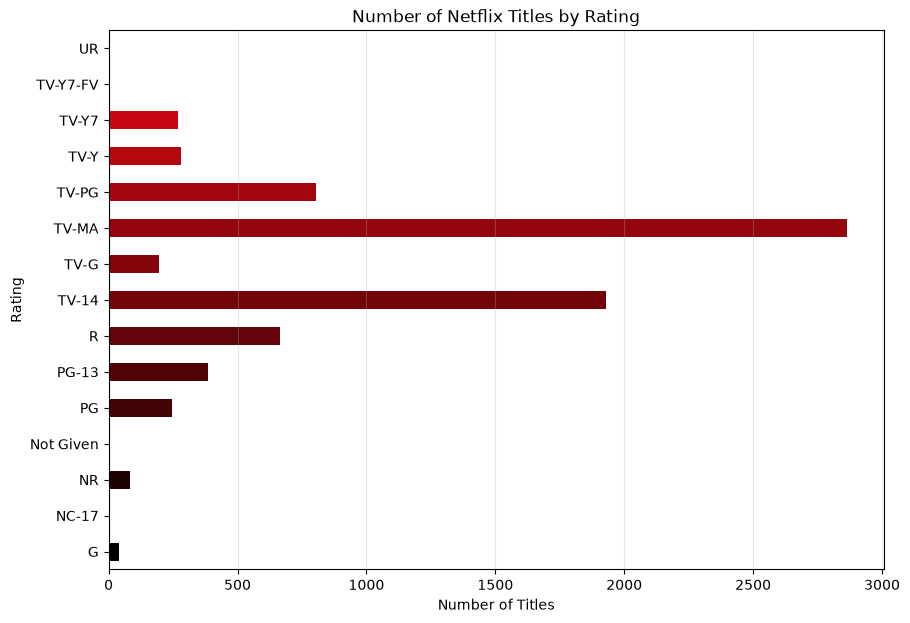

In [21]:
plt.figure(figsize=(10, 7))

rating_counts.sort_index().plot(
    kind = "barh",
    color = netflix_gradient(len(rating_counts))
)

plt.title("Number of Netflix Titles by Rating")
plt.xlabel("Number of Titles")
plt.ylabel("Rating")

plt.grid(axis="x", alpha=0.3)
plt.show()

### 5.3 Netflix Genres

In [22]:
# Split multiple genres and count each genre separately
genres = df['genres'].str.split(', ').explode() # Split multiple genres and expand them into separate rows for counting

In [23]:
top_genres = genres.value_counts().head(10)

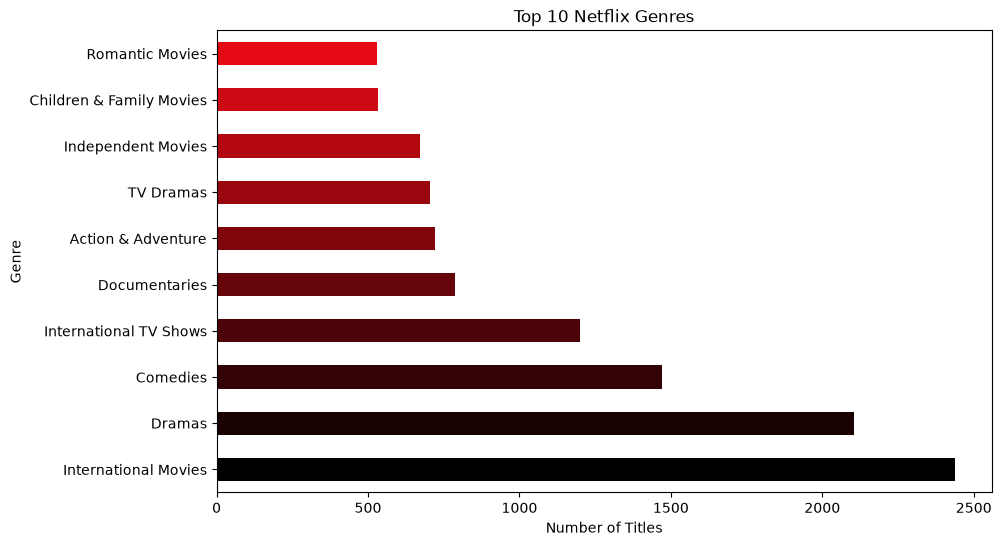

In [24]:
top_genres.plot(
    kind='barh',
    color=netflix_gradient(len(top_genres)),
    figsize=(10, 6)
)

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.show()

### 5.4 Content by Release Year

In [25]:
# Count Netflix titles by release year
release_years = df["release_year"].value_counts().sort_index()

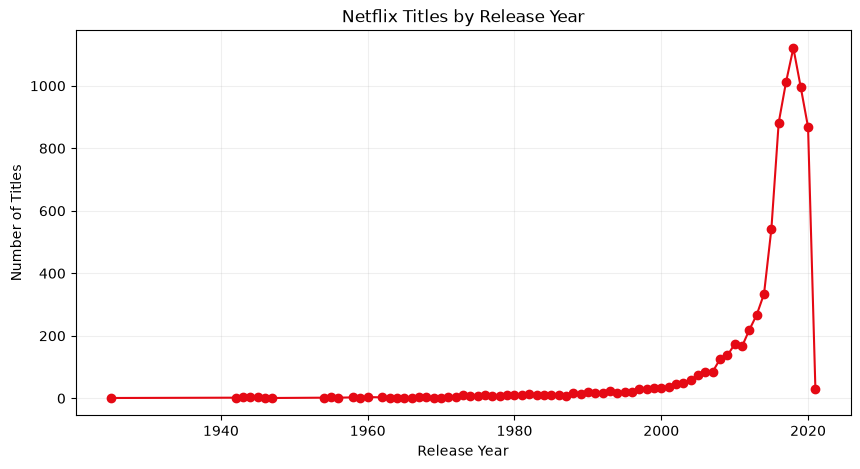

In [26]:
release_years.plot(figsize=(10, 5),
                   marker='o',
                   color='#E50914')

plt.title("Netflix Titles by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True, alpha=0.2)
plt.show()

### 5.5 Movies vs TV Shows: Release Year

In [27]:
# Compare release-year statistics and trends by content type
df.groupby('type')['release_year'].describe()  # Separate the data by type, then calculate statistics for release_year for each group

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Movie,5377.0,2012.920030,9.663282,1942.0,2012.0,2016.0,2018.0,2021.0
TV Show,2410.0,2016.191701,5.664826,1925.0,2015.0,2018.0,2019.0,2021.0


In [28]:
# Group by year and type, count them, and put Movies and TV Shows in separate columns
content_by_year = df.groupby(['release_year','type']).size().unstack(fill_value=0)   # fill_value = 0 -> To remove any empty values

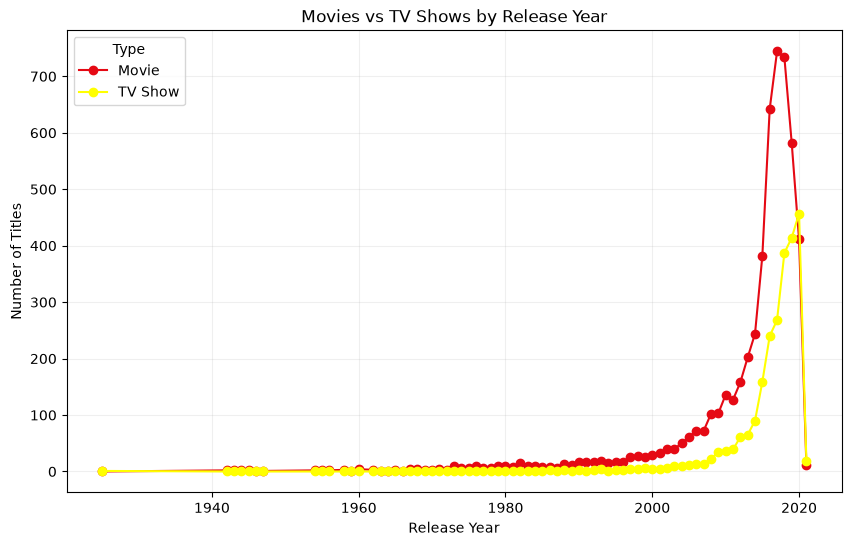

In [29]:
content_by_year.plot(
    kind = 'line',
    figsize = (10,6),
    marker = 'o',
    color=['#E50914', 'yellow'],
)
plt.title("Movies vs TV Shows by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend(title="Type")
plt.grid(True, alpha=0.2)
plt.show()

### 5.6 TV Show Seasons

In [30]:
# Separate TV Shows to analyze their season counts
tv_shows = df[df["type"] == "TV Show"]

In [31]:
tv_shows['duration'].describe()

count    2410.000000
mean        1.775934
std         1.596359
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        16.000000
Name: duration, dtype: float64

In [32]:
season_counts = tv_shows["duration"].value_counts().sort_index()

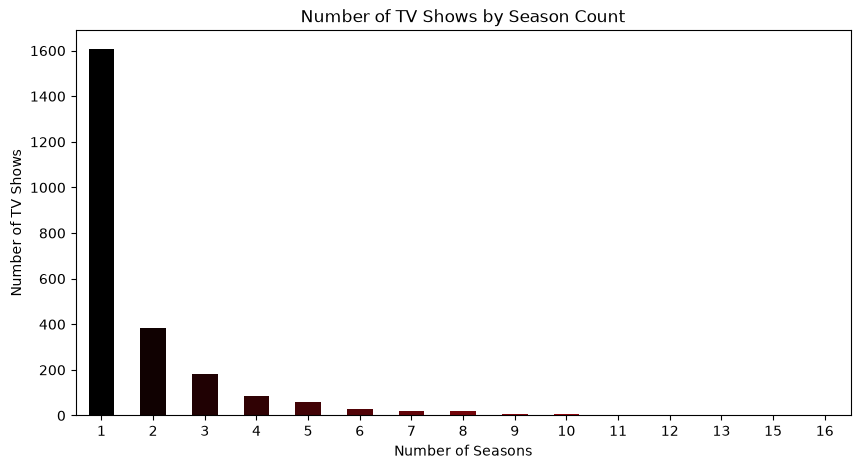

In [33]:
season_counts.plot(
    kind = 'bar',
    figsize = (10, 5),
    color = netflix_gradient(len(season_counts))
)

plt.title("Number of TV Shows by Season Count")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")
plt.xticks(rotation=0)
plt.show()

### 5.7 Top Countries by Netflix Titles

In [34]:
country_counts = (df["country"]
                  .str.split(', ')
                  .explode()
                  .value_counts()
                 )

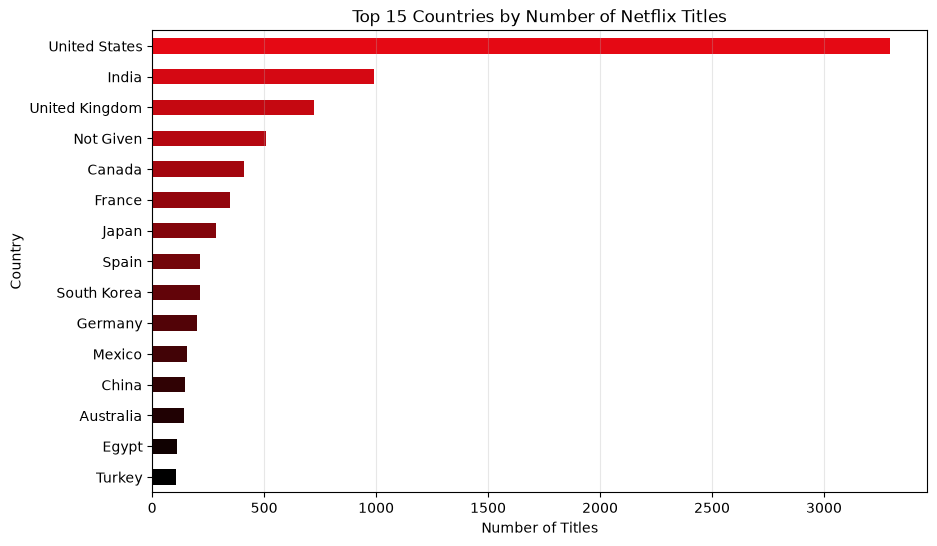

In [35]:
plt.figure(figsize = (10,6))

country_counts.head(15).sort_values().plot(
    kind = "barh",
    color = netflix_gradient(len(country_counts.head(15)))
)

plt.title("Top 15 Countries by Number of Netflix Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.grid(axis='x', alpha = 0.3)
plt.show()

### 5.8 Top Directors by Netflix Titles

In [36]:
# Exclude missing director values before counting titles
director_counts =  (df["director"]
                   .loc[df["director"] != "Not Given"]
                   .value_counts()
                   )

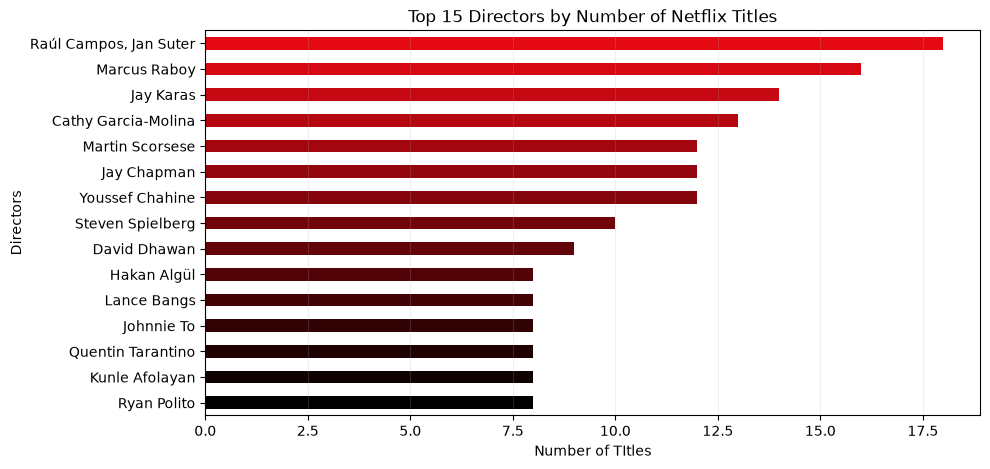

In [37]:
plt.figure(figsize = (10, 5))

director_counts.head(15).sort_values().plot(
    kind = "barh",
    color = netflix_gradient(len(director_counts.head(15)))
)

plt.title("Top 15 Directors by Number of Netflix Titles")
plt.xlabel("Number of TItles")
plt.ylabel("Directors")

plt.grid(axis='x', alpha=0.2)
plt.show()

### 5.9 Top Actors by Netflix Titles

In [38]:
cast_counts = (
    df['cast']
    .loc[df['cast'] != 'Not Given']
    .str.split(', ')
    .explode()
    .value_counts()
)

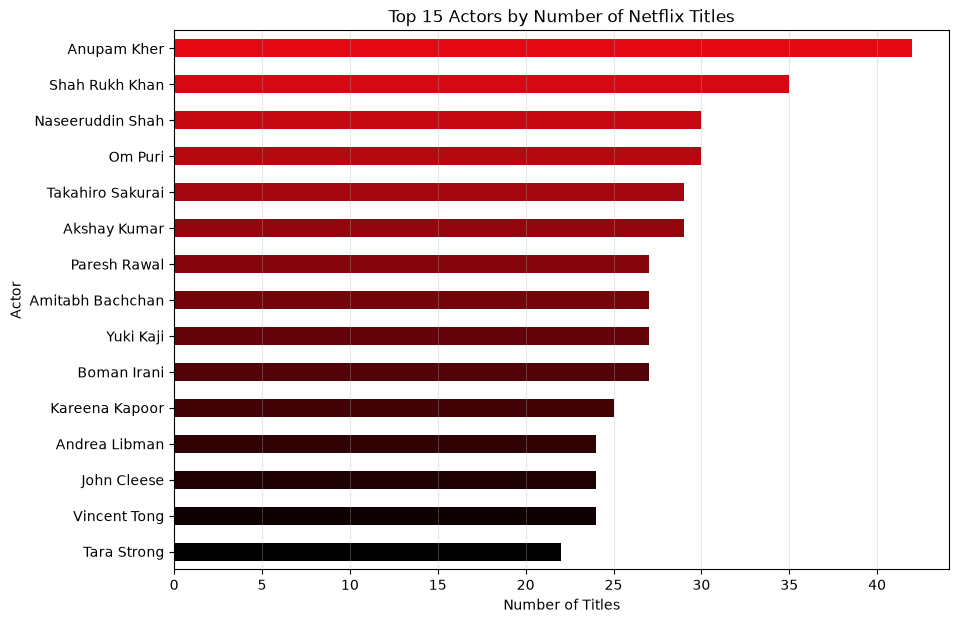

In [39]:
plt.figure(figsize=(10, 7))

cast_counts.head(15).sort_values().plot(
    kind='barh',
    color=netflix_gradient(len(cast_counts.head(15)))
)

plt.title('Top 15 Actors by Number of Netflix Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Actor')

plt.grid(axis='x', alpha=0.3)
plt.show()

### 5.10 Movie vs TV Show Genres

In [40]:
# Compare the most common genres in Movies and TV Shows
movie_genres = (
    df[df['type'] == 'Movie']['genres']
    .str.split(', ')
    .explode()
    .value_counts()
)

In [41]:
tv_genres = (
    df[df['type'] == 'TV Show']['genres']
    .str.split(', ')
    .explode()
    .value_counts()
)

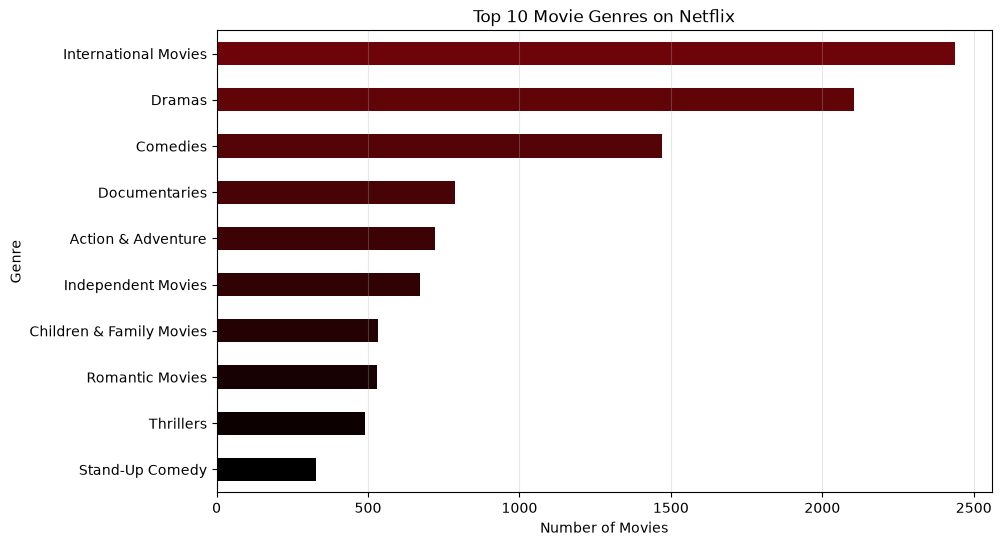

In [42]:
plt.figure(figsize=(10, 6))

movie_genres.head(10).sort_values().plot(
    kind = 'barh',
    color = netflix_gradient(len(movie_genres))
)

plt.title('Top 10 Movie Genres on Netflix')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')

plt.grid(axis = 'x', alpha = 0.3)
plt.show()

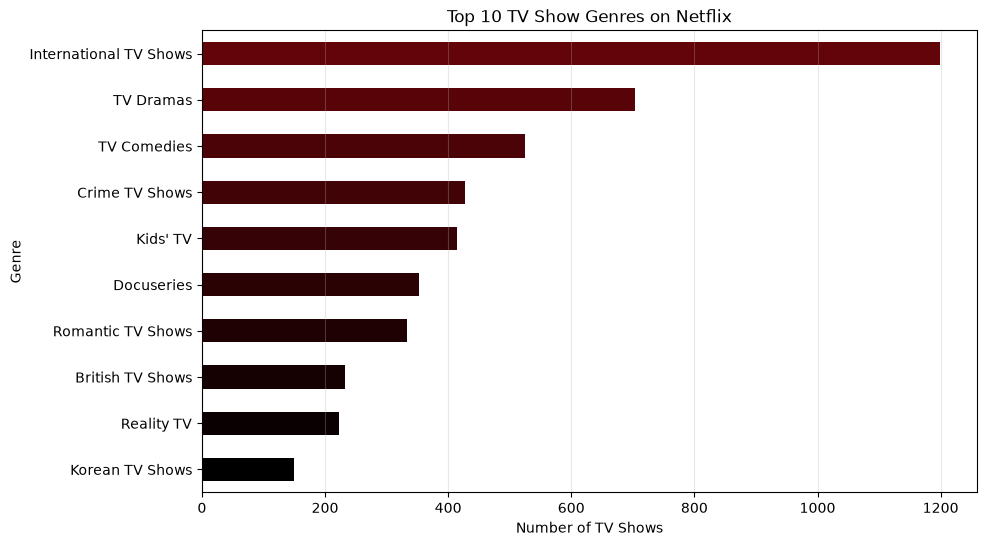

In [43]:
plt.figure(figsize = (10, 6))

tv_genres.head(10).sort_values().plot(
    kind = 'barh',
    color = netflix_gradient(len(tv_genres))
)

plt.title('Top 10 TV Show Genres on Netflix')
plt.xlabel('Number of TV Shows')
plt.ylabel('Genre')

plt.grid(axis = 'x', alpha = 0.3)
plt.show()

### 5.11 Titles Added to Netflix by Year

In [44]:
df['date_added_year'] = df['date_added'].dt.year

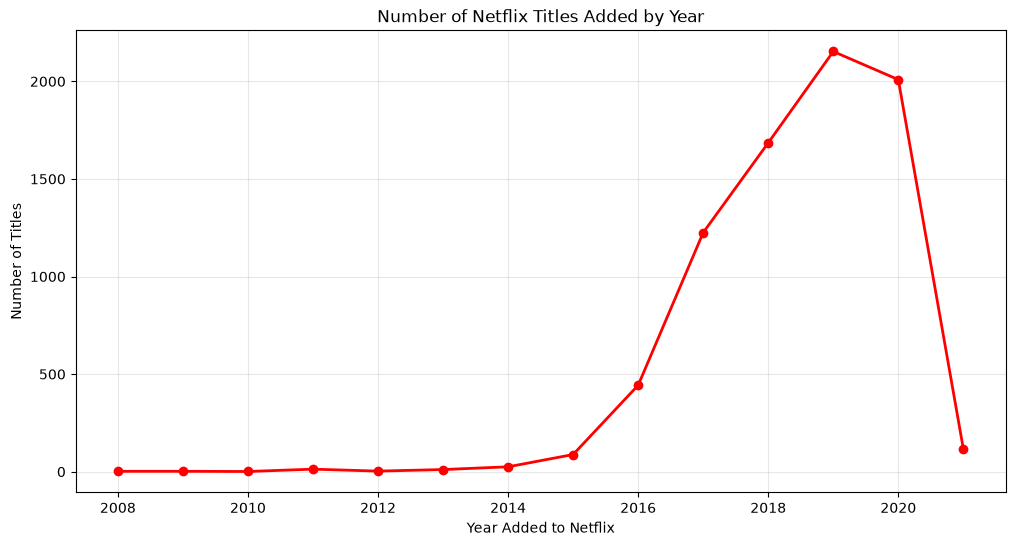

In [45]:
plt.figure(figsize = (12, 6))

plt.plot(
    df['date_added_year'].value_counts().sort_index().index,
    df['date_added_year'].value_counts().sort_index().values,
    color = 'red',
    linewidth = 2,
    marker = 'o'
)

plt.title('Number of Netflix Titles Added by Year')
plt.xlabel('Year Added to Netflix')
plt.ylabel('Number of Titles')

plt.grid(True, alpha = 0.3)
plt.show()

### 5.12 Movie Duration

In [46]:
# What is the typical runtime of movies available on Netflix?
movie_duration = df[df['type'] == 'Movie']['duration']

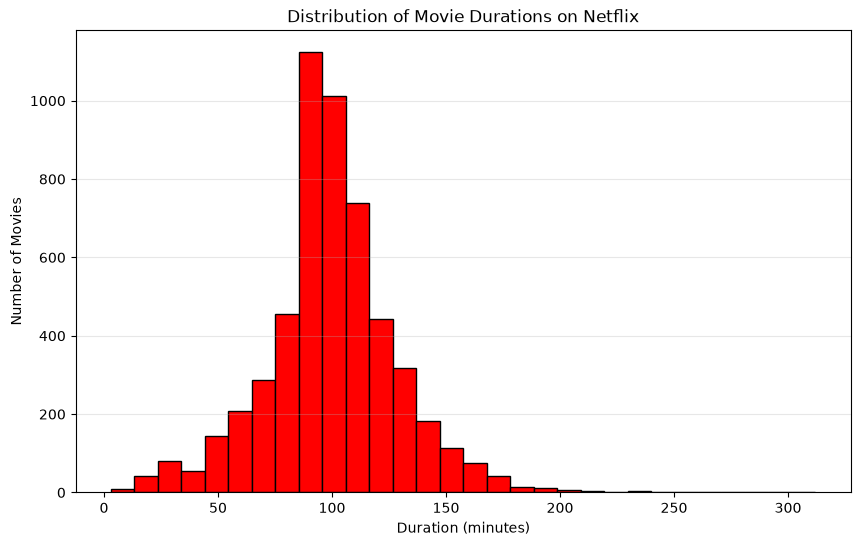

In [47]:
plt.figure(figsize=(10, 6))

plt.hist(
    movie_duration,
    bins=30,
    color= 'red',
    edgecolor='black'
)

plt.title('Distribution of Movie Durations on Netflix')
plt.xlabel('Duration (minutes)')
plt.ylabel('Number of Movies')

plt.grid(axis='y', alpha=0.3)
plt.show()

In [48]:
type_percentage = df['type'].value_counts(normalize=True) * 100

In [49]:
tv_ma_percentage = (df['rating'] == 'TV-MA').mean() * 100

In [50]:
genre_percentage = df['genres'].str.split(', ').explode().value_counts(normalize=True) * 100

In [51]:
season_percentage = (
    df[df['type'] == 'TV Show']['duration']
    .value_counts(normalize=True) * 100
)

In [52]:
recent_additions = (
    df['date_added_year']
    .between(2017, 2020)
    .mean() * 100
)

## Conclusion

This exploratory data analysis of the Netflix titles dataset provided insights into the composition and growth of Netflix's content library. Movies account for approximately 69% of the dataset, while TV Shows make up around 31%.

The analysis showed that TV-MA is the most common content rating, representing approximately 36.77% of all titles. International Movies were the most frequently occurring genre category, followed by Dramas and Comedies. Among TV Shows, 66.72% had only one season, indicating that shorter-running series were particularly common in the dataset.

Movie duration analysis showed that the typical Netflix movie had a runtime of approximately 98 minutes. The analysis of content addition dates also revealed significant catalog growth, with approximately 90.82% of the titles in the dataset being added between 2017 and 2020.

Overall, the analysis demonstrates how Python, Pandas, NumPy, and Matplotlib can be used to clean, explore, analyze, and visualize a real-world dataset. These findings provide a foundation for further analysis using SQL and Power BI.

In [53]:
df['type'].value_counts(normalize=True) * 100

type
Movie      69.050982
TV Show    30.949018
Name: proportion, dtype: float64

In [54]:
(df['rating'] == 'TV-MA').mean() * 100

np.float64(36.76640554770772)

In [55]:
(
    df[df['type'] == 'TV Show']['duration']
    .eq(1)
    .mean()
) * 100

np.float64(66.7219917012448)

In [56]:
df.loc[df['type'] == 'Movie', 'duration'].median()

np.float64(98.0)

In [57]:
df['date_added_year'].between(2017, 2020).mean() * 100

np.float64(90.81803005008348)